###0.Interpreter와 Notebook Kernel이 다르면 터미널에서는 설치된 패키지가 Notebook에서 보이지 않는 문제가 생길 수 있습니다

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\stage_1\dev\llm-data-analysis-course\.venv\Scripts\python.exe
Python version: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Current working directory: c:\stage_1\dev\llm-data-analysis-course\notebooks
pandas: 3.0.5
numpy: 2.5.3


기본 라이브러리 실행 오류 여부 확인.

현재 Python:
현재 Notebook Kernel:
현재 작업 폴더:
확인한 패키지:
환경에서 추가로 확인할 점: N/A

### STEP 02. Titanic 데이터 확보와 로딩 (프로젝트 루트찾기)

In [3]:

from pathlib import Path
def get_project_root(start_path: Path | None = None) -> Path:
    """현재 위치에서 상위 폴더를 탐색해 data 폴더가 있는 프로젝트 루트를 찾는다."""
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")

project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Titanic 데이터가 없습니다: {data_path}\n"
        "저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )

In [4]:
print("project_root : ",project_root)
print("data_path : ",data_path)

project_root :  C:\stage_1\dev\llm-data-analysis-course
data_path :  C:\stage_1\dev\llm-data-analysis-course\data\titanic\train.csv


프로젝트 root 및 데이터 파일 경로 가져오기 성공

02_2 데이터 로딩

In [5]:

import pandas as pd
df = pd.read_csv(data_path)
print("data path:", data_path)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

data path: C:\stage_1\dev\llm-data-analysis-course\data\titanic\train.csv
shape: (891, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


df = 원본 기준 데이터
df 기본 원본 관찰

STEP 03. 데이터 구조와 품질의 첫인상 확인
03_1. 크기와 앞부분 확인

In [6]:
print("shape:", df.shape)
df.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


03_2. dtype과 기본 구조 확인

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


어떤 컬럼이 숫자형인가?
어떤 컬럼이 문자열인가?
숫자로 저장되어 있지만 실제 의미는 범주형인 컬럼이 있는가? survived, pclass,
결측치가 보이는가? 5번 10번 11번

02_3.결측치 요약 (결측치 갯수 요약, 가장 많은 결측치 부터 맨 위로 나오게 함. )

In [9]:

missing_count = df.isna().sum()
missing_rate = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_pct": missing_rate,
}).sort_values("missing_count", ascending=False)
missing_summary

,missing_count,missing_rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


02_4. 중복과 기초 통계

In [8]:
print("duplicate rows:", df.duplicated().sum())
df.describe(include="all")

duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [11]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

★ 개인 판단 지점 1
학생이 추가로 확인하고 싶은 데이터 품질 항목을 하나 선택합니다.

- PassengerId 중복 여부
- Age 범위
- Fare 이상치
- 각 범주형 컬럼의 unique 개수
- Sex / Embarked / Pclass의 값 분포

현재 STEP 03 실행 결과를 기준으로
추가로 확인할 가치가 있는 데이터 품질 분석 후보 3개를 제안해 주세요.
각 후보에 대해
1. 무엇을 확인하는지
2. 왜 필요한지
3. 결과에 따라 다음 판단이 어떻게 달라지는지
를 설명해 주세요.
| 후보                       | 무엇을 확인하는지                       | 왜 필요한지                                                                | 결과에 따라 다음 판단                                             |
| ------------------------ | ------------------------------- | --------------------------------------------------------------------- | -------------------------------------------------------- |
| **1. PassengerId 중복 여부** | `PassengerId`가 승객마다 고유한지 확인     | 전체 행 중복이 0이어도 **ID만 중복된 행**은 있을 수 있음. 식별자 중복은 한 승객이 여러 번 기록된 문제일 수 있음 | 중복 없음 → 식별자로 사용 가능 / 중복 있음 → 중복 원인 확인 후 제거·통합 여부 판단      |
| **2. Age 범위와 비정상값 확인**   | 나이가 음수인지, 지나치게 크거나 작은 값이 있는지 확인 | `Age`는 결측치가 177개이고 실제 분석·생존율 비교에 자주 쓰이는 변수라 품질이 중요함                   | 값이 정상 범위 → 결측치 처리만 고민 / 비정상값 존재 → 결측 처리 전 오류값 수정·제외 판단   |
| **3. Fare 이상치 확인**       | 다른 승객보다 지나치게 큰 운임 값이 있는지 확인     | `Fare`의 중앙값은 약 14.45인데 최대값은 512.33이라 극단값 가능성이 큼                       | 실제 고가 운임 → 유지 / 입력 오류 → 수정·제외 / 분석 왜곡 우려 → 로그변환·구간화 등 검토 |


STEP 04. 분석 문제와 Target 정의
04_1 Target 확인

In [11]:
print("Survived missing:", df["Survived"].isna().sum())
print("Survived unique:", sorted(df["Survived"].dropna().unique()))
print("\nClass count")
print(df["Survived"].value_counts().sort_index())
print("\nClass ratio")
print(df["Survived"].value_counts(normalize=True).sort_index())

Survived missing: 0
Survived unique: [np.int64(0), np.int64(1)]

Class count
Survived
0    549
1    342
Name: count, dtype: int64

Class ratio
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Survived가 0과 1 두 범주이므로 이번 문제는 기본적으로 이진 분류(Binary Classification) 문제입니다.

04_02 Feature와 Target (Feature는 우리에게 주어진 컬럼들이고, 정답을 뺀 나머지 컬럼들을 Feature라고 함.)

Feature = 예측에 사용할 입력 정보
Target  = 맞히고 싶은 정답 

예를 들어 Sex, Pclass, Age, Fare 등은 Feature 후보가 될 수 있고 Survived는 Target입니다.

내가 정의한 분석 문제:
이 문제의 Target:
이 문제를 분류 문제라고 판단한 이유:

STEP 05. 결측치 처리

In [13]:
df_work = df.copy()

결측치 다시 확인 

In [10]:
missing_summary = pd.DataFrame({
    "count": df_work.isna().sum(),
    "rate_pct": (df_work.isna().mean() * 100).round(2),
}).sort_values("count", ascending=False)
missing_summary

NameError: name 'df_work' is not defined

In [17]:
age_median = df_work["Age"].median()
embarked_mode = df_work["Embarked"].mode().iloc[0]
df_work["Age"] = df_work["Age"].fillna(age_median)
df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode)

In [18]:
df_work[["Age", "Embarked", "Cabin"]].isna().sum()

Age           0
Embarked      0
Cabin       687
dtype: int64

STEP 06. 불필요한 컬럼 검토

KEEP    = 그대로 사용할 후보
EXCLUDE = 모델 입력에서는 제외할 후보 (기계학습을 시킬 컬럼들)
DERIVE  = 새로운 Feature를 만들 재료
DEFER   = 지금 결정하지 않고 보류

STEP 07. 범주형 데이터 변환 원리 이해

In [19]:
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"\n[{col}]")
    print(df_work[col].value_counts(dropna=False))


[Sex]
Sex
male      577
female    314
Name: count, dtype: int64

[Embarked]
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

[Pclass]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


###교육용 인코딩 branch  글자를 숫자로 바꾸는것을 인코딩이라고 해. 
인코딩: 범주형 데이터는 

In [20]:
df_encoded = df_work.copy()

In [22]:

df_encoded["SexMapped"] = df_encoded["Sex"].map({
    "male": 0,
    "female": 1,
})
df_encoded[["Sex", "SexMapped"]]

,Sex,SexMapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0
...,...,...
886,male,0
887,female,1
888,female,1
889,male,0


One-Hot Encoding 예시
Embarked처럼 명목형 범주에 임의로 0, 1, 2를 부여하면 존재하지 않는 순서 관계를 모델이 해석할 수 있습니다.
교육용으로 pd.get_dummies()를 사용해 원리를 확인합니다.

In [23]:
embarked_dummies = pd.get_dummies(
    df_encoded["Embarked"],
    prefix="Embarked",
    dtype=int,
)
embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


STEP 08. 시각화와 기본 패턴 확인

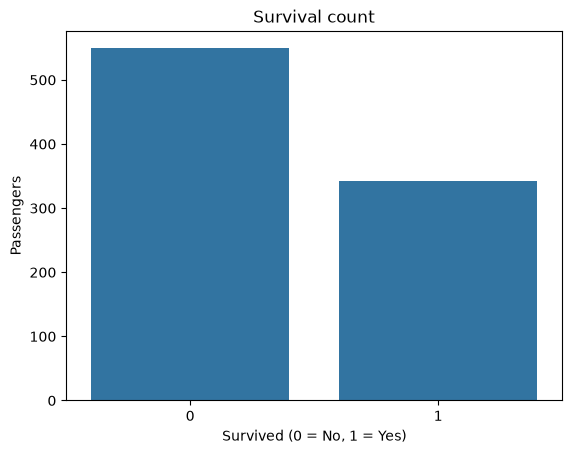

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df_work, x="Survived")
plt.title("Survival count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passengers")
plt.show()

질문 2. 성별에 따라 생존율이 다른가?

In [ ]:

sex_survival = (
    df_work.groupby("Sex", as_index=False)["Survived"]
    .mean()
)
sns.barplot(data=sex_survival, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

질문 3. 객실 등급에 따라 생존율이 다른가?

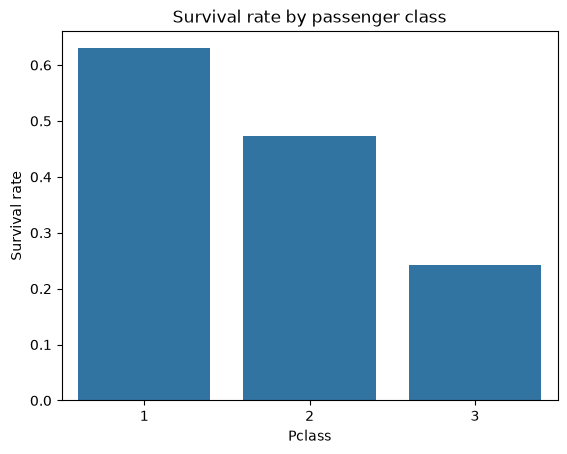

In [25]:
pclass_survival = (

    df_work.groupby("Pclass", as_index=False)["Survived"]
    .mean()

)
sns.barplot(data=pclass_survival, x="Pclass", y="Survived")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.show()

질문 4. 나이와 생존 사이에 어떤 패턴이 보이는가?

In [ ]:
sns.histplot(

    data=df_work,
    x="Age",
    hue="Survived",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,

)
plt.title("Age distribution by survival")
plt.show()

질문 5. Fare와 생존 사이에 어떤 패턴이 보이는가?

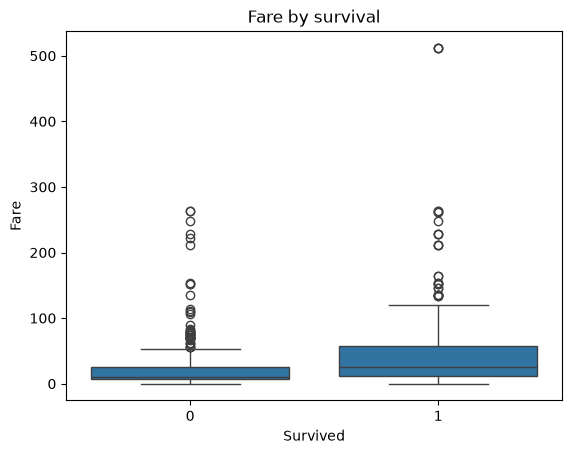

In [26]:
sns.boxplot(data=df_work, x="Survived", y="Fare")
plt.title("Fare by survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

STEP 09. 기초 통계와 EDA

In [13]:
df_work = df.copy()
display(df_work.groupby("Sex").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))
display(df_work.groupby("Pclass").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))
display(df_work.groupby(["Sex", "Pclass"]).agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


,rows,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


rows  survival_rate
Sex    Pclass                     
female 1         94       0.968085
       2         76       0.921053
       3        144       0.500000
male   1        122       0.368852
       2        108       0.157407
       3        347       0.135447

In [14]:
from scipy import stats
survived = df_work.loc[df_work["Survived"] == 1, "Fare"]
not_survived = df_work.loc[df_work["Survived"] == 0, "Fare"]
t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)
print("survived Fare mean:", round(survived.mean(), 2), " n =", survived.shape[0])
print("not survived Fare mean:", round(not_survived.mean(), 2), " n =", not_survived.shape[0])
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.3e}")

survived Fare mean: 48.4  n = 342
not survived Fare mean: 22.12  n = 549
t-statistic: 6.8391
p-value: 2.699e-11


In [15]:
feature_demo = df_work.copy()
feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1
feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)
display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


In [18]:
model_source = feature_demo.copy()

In [19]:
model_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [ ]:
# 모델에 사용할 Feature
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

In [23]:
model_source[["Parch","IsAlone"]]
model_source [feature_columns].head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


학습셋이랑 모의고사 테스트셋이랑 바로 나누면 안된다? 가장 간단하게 하는방법은? 그리고 저거 왜 저렇게 두개 나눠야하는데? sex랑 embarked가 str인데, 이걸 int로 바꾸면되는거 아닌가?

In [24]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy() # y는 정답.

print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

X: (891, 9)
y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

그리고 마지막 셀에서 학습용/테스트용 데이터로 분리합니다.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape, y_train.shape) #트레인은 공부하는것. 문제와 정답.
print("test :", X_test.shape, y_test.shape) #문항갯수, 정답갯수

train: (712, 9) (712,)
test : (179, 9) (179,)


분리가 잘 되었는지 생존 비율도 확인합니다.

In [27]:
print("전체 데이터")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .rename("ratio")
     .to_frame()
)

print("학습 데이터")
display(
    y_train.value_counts(normalize=True)
           .sort_index()
           .rename("train_ratio")
           .to_frame()
)

print("테스트 데이터")
display(
    y_test.value_counts(normalize=True)
          .sort_index()
          .rename("test_ratio")
          .to_frame()
)

전체 데이터


,ratio
Survived,
0,0.616162
1,0.383838


학습 데이터


,train_ratio
Survived,
0,0.616573
1,0.383427


테스트 데이터


,test_ratio
Survived,
0,0.614525
1,0.385475


In [ ]:
import sys

src_path = project_root / "src"

if str(src_path) not in sys.path:

    sys.path.insert(0, str(src_path))

from titanic_app.features import (
    RAW_INPUT_COLUMNS, MODEL_FEATURE_COLUMNS,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    build_model_features,

)

from sklearn.model_selection import train_test_split

model_source = build_model_features(df.copy())
X = model_source[MODEL_FEATURE_COLUMNS].copy()
y = model_source["Survived"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y

)
print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)
display(y_train.value_counts(normalize=True).sort_index().rename("train_ratio").to_frame())
display(y_test.value_counts(normalize=True).sort_index().rename("test_ratio").to_frame())

In [40]:
raw_input_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]

feature_columns = raw_input_columns + ["FamilySize", "IsAlone"]

numeric_features = [
    "Age", "SibSp", "Parch", "Fare", "FamilySize"
]

categorical_features = [
    "Pclass", "Sex", "Embarked", "IsAlone"
]

In [41]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

In [42]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

1. 숫자형 결측치 처리
2. 범주형 결측치 처리
3. One-Hot Encoding
4. 정규화와 표준화 개념 비교
5. StandardScaler 표준화
6. 숫자형 + 범주형 데이터 결합
7. Logistic Regression 학습

In [43]:
from sklearn.impute import SimpleImputer
numeric_imputer = SimpleImputer(strategy="median")
X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,

)

In [50]:
X_train_cat_imputed = X_train[categorical_features].copy()
X_test_cat_imputed = X_test[categorical_features].copy()

X_train_cat_imputed = X_train_cat_imputed.fillna(
    X_train_cat_imputed.mode().iloc[0]
)

X_test_cat_imputed = X_test_cat_imputed.fillna(
    X_train_cat_imputed.mode().iloc[0]
)

In [59]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_FEATURES = ["Sex", "Embarked"]
# 1. 문자형 데이터 분리
X_train_cat = X_train[CATEGORICAL_FEATURES].copy()
X_test_cat = X_test[CATEGORICAL_FEATURES].copy()

# 2. 학습 데이터의 최빈값으로 결측값 채우기
train_modes = X_train_cat.mode().iloc[0]

X_train_cat = X_train_cat.fillna(train_modes)
X_test_cat = X_test_cat.fillna(train_modes)

# 3. 원-핫 인코더 생성
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# 4. 학습 데이터는 학습하면서 변환
X_train_cat_array = encoder.fit_transform(X_train_cat)

# 5. 테스트 데이터는 학습된 기준으로 변환만
X_test_cat_array = encoder.transform(X_test_cat)

# 6. 인코딩 후 생성된 열 이름
encoded_columns = encoder.get_feature_names_out(
    CATEGORICAL_FEATURES
)

# 7. 배열을 DataFrame으로 변환
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_array,
    columns=encoded_columns,
    index=X_train.index
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_array,
    columns=encoded_columns,
    index=X_test.index
)

# 8. 결과 확인
print("학습 데이터 크기:", X_train_cat_encoded.shape)
print("테스트 데이터 크기:", X_test_cat_encoded.shape)

display(X_train_cat_encoded.head())

학습 데이터 크기: (712, 5)
테스트 데이터 크기: (179, 5)


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
692,0.0,1.0,0.0,0.0,1.0
481,0.0,1.0,0.0,0.0,1.0
527,0.0,1.0,0.0,0.0,1.0
855,1.0,0.0,0.0,0.0,1.0
801,1.0,0.0,0.0,0.0,1.0


In [60]:

from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()

minmax_preview = pd.DataFrame(

    minmax_demo.fit_transform(
        X_train_num_imputed[["Age", "Fare"]]

    ),

    columns=["Age_minmax", "Fare_minmax"],
    index=X_train.index,

)
display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.352852,0.110272
481,0.352852,0.000000
527,0.352852,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(

    scaler.fit_transform(X_train_num_imputed),
    columns=numeric_features,
    index=X_train.index,

)

X_test_num_scaled = pd.DataFrame(

    scaler.transform(X_test_num_imputed),
    columns=numeric_features,
    index=X_test.index,

)

In [63]:

X_train_ready = pd.concat(
    [X_train_num_scaled, X_train_cat_encoded],
    axis=1,

)

X_test_ready = pd.concat(

    [X_test_num_scaled, X_test_cat_encoded],
    axis=1,
)

#머신러닝 모델

In [79]:
from sklearn import set_config
from sklearn.linear_model import LogisticRegression

set_config(display="text")

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

baseline_model.fit(X_train_ready, y_train)

print("모델 학습 완료")

모델 학습 완료


In [80]:

from sklearn.ensemble import RandomForestClassifier

additional_model = RandomForestClassifier(

    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,

)

additional_model.fit(X_train_ready, y_train)
additional_pred = additional_model.predict(X_test_ready)

In [85]:
from sklearn.metrics import accuracy_score, f1_score
baseline_pred = baseline_model.predict(X_test_ready)
additional_pred = additional_model.predict(X_test_ready)

model_compare = [
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "f1": f1_score(y_test, baseline_pred),
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, additional_pred),
        "f1": f1_score(y_test, additional_pred),
    },
]

display(model_compare)

[{'model': 'Logistic Regression',
  'accuracy': 0.7988826815642458,
  'f1': 0.71875},
 {'model': 'Random Forest', 'accuracy': 0.8044692737430168, 'f1': 0.72}]

In [87]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
scaler = StandardScaler()

In [90]:
X_train_num = numeric_imputer.fit_transform(X_train[NUMERIC_FEATURES])
X_test_num = numeric_imputer.transform(X_test[NUMERIC_FEATURES])

X_train_cat = categorical_imputer.fit_transform(
    X_train[CATEGORICAL_FEATURES]
)
X_test_cat = categorical_imputer.transform(
    X_test[CATEGORICAL_FEATURES]
)

X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)

X_train_ready = scaler.fit_transform(X_train_num)
X_test_ready = scaler.transform(X_test_num)
final_model = baseline_model

NameError: name 'NUMERIC_FEATURES' is not defined

In [86]:

import json

import joblib

models_dir = project_root / "models"

models_dir.mkdir(parents=True, exist_ok=True)

bundle_path = models_dir / "titanic_model_bundle.joblib"

contract_path = models_dir / "titanic_model_contract.json"

model_bundle = {

    "numeric_imputer": numeric_imputer,
    "categorical_imputer": categorical_imputer,
    "encoder": encoder,
    "scaler": scaler,
    "model": final_model,

}

joblib.dump(model_bundle, bundle_path)

NameError: name 'categorical_imputer' is not defined

In [74]:

model_contract = {

    "task": "binary_classification",

    "target": "Survived",

    "positive_class": 1,

    "raw_input_columns": raw_input_columns,

    "model_feature_columns": feature_columns,

    "numeric_features": numeric_features,

    "categorical_features": categorical_features,

    "prepared_feature_columns": X_train_ready.columns.tolist(),

    "derived_features": ["FamilySize", "IsAlone"],

    "scaling": "StandardScaler",

    "final_estimator": type(final_model).__name__,

}

NameError: name 'final_model' is not defined

In [75]:
loaded_bundle = joblib.load(bundle_path)

new_passenger = pd.DataFrame([{

    "Pclass": 3,
    "Sex": "male",
    "Age": 30.0,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 10.0,
    "Embarked": "S",
}])

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\stage_1\\dev\\llm-data-analysis-course\\models\\titanic_model_bundle.joblib'

In [76]:

new_passenger["FamilySize"] = (
    new_passenger["SibSp"] + new_passenger["Parch"] + 1

)

new_passenger["IsAlone"] = (
    new_passenger["FamilySize"] == 1
).astype(int)

NameError: name 'new_passenger' is not defined

In [77]:

new_num_imputed = loaded_bundle["numeric_imputer"].transform(

    new_passenger[numeric_features]

)

new_num_scaled = loaded_bundle["scaler"].transform(new_num_imputed)

new_cat_imputed = loaded_bundle["categorical_imputer"].transform(

    new_passenger[categorical_features]

)

new_cat_encoded = loaded_bundle["encoder"].transform(new_cat_imputed)

new_ready = pd.DataFrame(

    np.hstack([new_num_scaled, new_cat_encoded]),
    columns=model_contract["prepared_feature_columns"],

)

NameError: name 'loaded_bundle' is not defined

In [78]:

loaded_model = loaded_bundle["model"]

new_prediction = int(loaded_model.predict(new_ready)[0])

positive_index = list(loaded_model.classes_).index(1)

positive_probability = float(
    loaded_model.predict_proba(new_ready)[0][positive_index]

)

NameError: name 'loaded_bundle' is not defined